# Generate Recommendation Rate Heatmap

This notebook recreates the recommendation-rate heatmap from the already-run Hive pivot result.

In [1]:
import os
import tempfile
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "comp810-matplotlib"))
os.environ.setdefault("XDG_CACHE_HOME", str(Path(tempfile.gettempdir()) / "comp810-cache"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Rectangle
from matplotlib.transforms import Bbox

In [2]:
def find_project_root(start=Path.cwd()):
    for path in [start, *start.parents]:
        if (path / "pipeline/hive/Results_from_Hive").exists():
            return path
    raise FileNotFoundError("Could not find the COMP810 project root from the current working directory.")


PROJECT_ROOT = find_project_root()
INPUT_PATH = PROJECT_ROOT / "pipeline/hive/Results_from_Hive/Profile-aware aggregation for recommendation-oriented analysis.xlsx"
OUTPUT_PATH = PROJECT_ROOT / "pipeline/hive/visuals/Recommendation rate heatmap by category and skin type.png"

print("Project root:", PROJECT_ROOT)
print("Input:", INPUT_PATH)
print("Output:", OUTPUT_PATH)

Project root: /Users/nwaysandioo/assignment_projects/2nd sem 2026/COMP810 Datawarehousing
Input: /Users/nwaysandioo/assignment_projects/2nd sem 2026/COMP810 Datawarehousing/pipeline/hive/Results_from_Hive/Profile-aware aggregation for recommendation-oriented analysis.xlsx
Output: /Users/nwaysandioo/assignment_projects/2nd sem 2026/COMP810 Datawarehousing/pipeline/hive/visuals/Recommendation rate heatmap by category and skin type.png


In [3]:
CATEGORY_LABELS = {
    "Lip Balms & Treatments": "Lip Balms",
    "Value & Gift Sets": "Gift Sets",
}

CATEGORY_ORDER = [
    "Cleansers",
    "Eye Care",
    "Lip Balms",
    "Masks",
    "Mini Size",
    "Moisturizers",
    "Treatments",
    "Gift Sets",
]

In [4]:
def read_pivot_result(path: Path) -> pd.DataFrame:
    """Read the Excel pivot table exported from Hive results."""
    raw = pd.read_excel(path, header=None)

    header_idx = raw.index[raw.iloc[:, 0].eq("Row Labels")][0]
    columns = raw.iloc[header_idx, 1:].dropna().astype(str).tolist()

    data = raw.iloc[header_idx + 1 :, : len(columns) + 1].copy()
    data.columns = ["category", *columns]
    data = data.dropna(subset=["category"])
    data["category"] = data["category"].replace(CATEGORY_LABELS)

    for col in columns:
        data[col] = pd.to_numeric(data[col], errors="coerce")

    # Match the submitted figure: keep categories with enough skin-type coverage.
    data = data[data[columns].notna().sum(axis=1) >= 4]
    data["category"] = pd.Categorical(data["category"], categories=CATEGORY_ORDER, ordered=True)

    return data.sort_values("category").set_index("category")[columns]


pivot = read_pivot_result(INPUT_PATH)
pivot

,combination,dry,normal,oily,unknown
category,,,,,
Cleansers,0.843173,0.840007,0.833452,0.832094,0.829268
Eye Care,0.848067,0.845258,0.826029,0.833509,0.748837
Lip Balms,0.830440,0.810007,0.812051,0.825706,0.790323
Masks,0.856932,0.840657,0.836493,0.865213,0.847303
Mini Size,0.827887,0.826844,0.818121,0.830820,0.778338
Moisturizers,0.871595,0.867424,0.872149,0.860756,0.844156
Treatments,0.838101,0.847909,0.849140,0.837353,0.835443
Gift Sets,0.864629,0.797170,0.858974,0.847716,NaN


In [5]:
# Shared report theme: teal ramp from the popularity/price scatter, typography
# and grey ink matching the "Review Count by Skin Type" chart.
TEAL_SEQ = LinearSegmentedColormap.from_list(
    "seq_teal", ["#ffffff", "#c9ecea", "#93dbd7", "#4cbfba", "#00a09a", "#0a7a76", "#0a5b58"])
INK, MUTED, FRAME = "#595959", "#8c8c8c", "#d9d9d9"
FONT = ["PT Sans", "Helvetica Neue", "Helvetica", "DejaVu Sans"]
RAMP_FLOOR = 0.20   # lightest cell stays clearly teal, never near-white

plt.rcParams.update({"font.family": "sans-serif", "font.sans-serif": FONT})


def ink_on(rgba):
    """Pick text colour from the cell's own luminance (WCAG relative luminance)."""
    lin = [c / 12.92 if c <= 0.04045 else ((c + 0.055) / 1.055) ** 2.4 for c in rgba[:3]]
    luminance = 0.2126 * lin[0] + 0.7152 * lin[1] + 0.0722 * lin[2]
    return "#ffffff" if luminance < 0.42 else "#0a3a38"


def ramp(norm):
    """Map 0-1 onto the usable part of the teal ramp."""
    return TEAL_SEQ(RAMP_FLOOR + norm * (1 - RAMP_FLOOR))


def draw_heatmap(pivot: pd.DataFrame, output: Path) -> None:
    """Draw the recommendation-rate heatmap in the shared report theme."""
    values = pivot.to_numpy(dtype=float)
    valid_values = values[~np.isnan(values)]
    vmin = float(valid_values.min())
    vmax = float(valid_values.max())

    fig, ax = plt.subplots(figsize=(7.16, 5.2), dpi=300)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")
    fig.patch.set_facecolor("white")
    ax.patch.set_visible(False)   # let the figure-level frame show through

    # No in-figure title: the LaTeX \\caption carries it.
    left = 0.235
    top = 0.77
    cell_w = 0.122
    cell_h = 0.045
    label_x = left - 0.015
    headers = list(pivot.columns)
    rows = list(pivot.index.astype(str))

    for col_idx, header in enumerate(headers):
        ax.text(left + cell_w * (col_idx + 0.5), top + 0.032, header, ha="center", va="center", fontsize=8.5, fontweight="bold", color=INK)

    for row_idx, row_name in enumerate(rows):
        y = top - cell_h * (row_idx + 1)
        ax.text(label_x, y + cell_h / 2, row_name, ha="right", va="center", fontsize=8.5, color=INK)

        for col_idx, value in enumerate(values[row_idx]):
            x = left + cell_w * col_idx

            if np.isnan(value):
                # neutral grey: no hue, so it never reads as a low value on the teal ramp
                face, text, text_color, style = "#f2f2f2", "N/A", MUTED, "italic"
            else:
                face = ramp((value - vmin) / (vmax - vmin))
                text = f"{value * 100:.1f}%"
                text_color, style = ink_on(face), "normal"

            # a white gap between cells, not a drawn border
            ax.add_patch(Rectangle((x, y), cell_w, cell_h, facecolor=face, edgecolor="white", linewidth=1.5))
            ax.text(x + cell_w / 2, y + cell_h / 2, text, ha="center", va="center", fontsize=8, fontweight="bold", fontstyle=style, color=text_color)

    legend_y = top - cell_h * len(rows) - 0.038
    legend_x = 0.36
    box_w = 0.045
    box_h = 0.018
    ax.text(legend_x - 0.025, legend_y + box_h / 2, f"Lower ({vmin * 100:.1f}%)", ha="right", va="center", fontsize=8.5, color=INK)

    for i in range(8):
        ax.add_patch(Rectangle((legend_x + i * box_w, legend_y), box_w, box_h, facecolor=ramp(i / 7), edgecolor="white", linewidth=0.8))

    ax.text(legend_x + 8 * box_w + 0.018, legend_y + box_h / 2, f"Higher ({vmax * 100:.1f}%)", ha="left", va="center", fontsize=8.5, color=INK)
    ax.text(0.5, legend_y - 0.034, "N/A cells did not meet the reporting threshold in the pivot output.", ha="center", va="center", fontsize=8, color=MUTED)

    # --- crop to the drawn content -----------------------------------------
    # A 10x10 canvas with axis("off") still hands bbox_inches="tight" the full
    # axes box, which is where the empty band under the note came from. Measure
    # the artists instead, then frame that box.
    fig.canvas.draw()
    rend = fig.canvas.get_renderer()
    content_px = Bbox.union([a.get_window_extent(rend) for a in list(ax.texts) + list(ax.patches)])

    pad_px = 0.20 * fig.dpi
    frame_px = Bbox.from_extents(content_px.x0 - pad_px, content_px.y0 - pad_px,
                                 content_px.x1 + pad_px, content_px.y1 + pad_px)

    # frame drawn in data coords so it renders with the rest of the axes content
    f = frame_px.transformed(ax.transData.inverted())
    ax.add_patch(Rectangle((f.x0, f.y0), f.width, f.height, facecolor="none",
                           edgecolor=FRAME, linewidth=1.0, zorder=0, clip_on=False))

    margin_px = 0.05 * fig.dpi
    save_box = Bbox.from_extents(frame_px.x0 - margin_px, frame_px.y0 - margin_px,
                                 frame_px.x1 + margin_px, frame_px.y1 + margin_px
                                 ).transformed(fig.dpi_scale_trans.inverted())

    output.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output, bbox_inches=save_box)
    fig.savefig(output.with_suffix(".svg"), bbox_inches=save_box)
    plt.close(fig)


Wrote /Users/nwaysandioo/assignment_projects/2nd sem 2026/COMP810 Datawarehousing/pipeline/hive/visuals/Recommendation rate heatmap by category and skin type.png
Wrote /Users/nwaysandioo/assignment_projects/2nd sem 2026/COMP810 Datawarehousing/pipeline/hive/visuals/Recommendation rate heatmap by category and skin type.svg


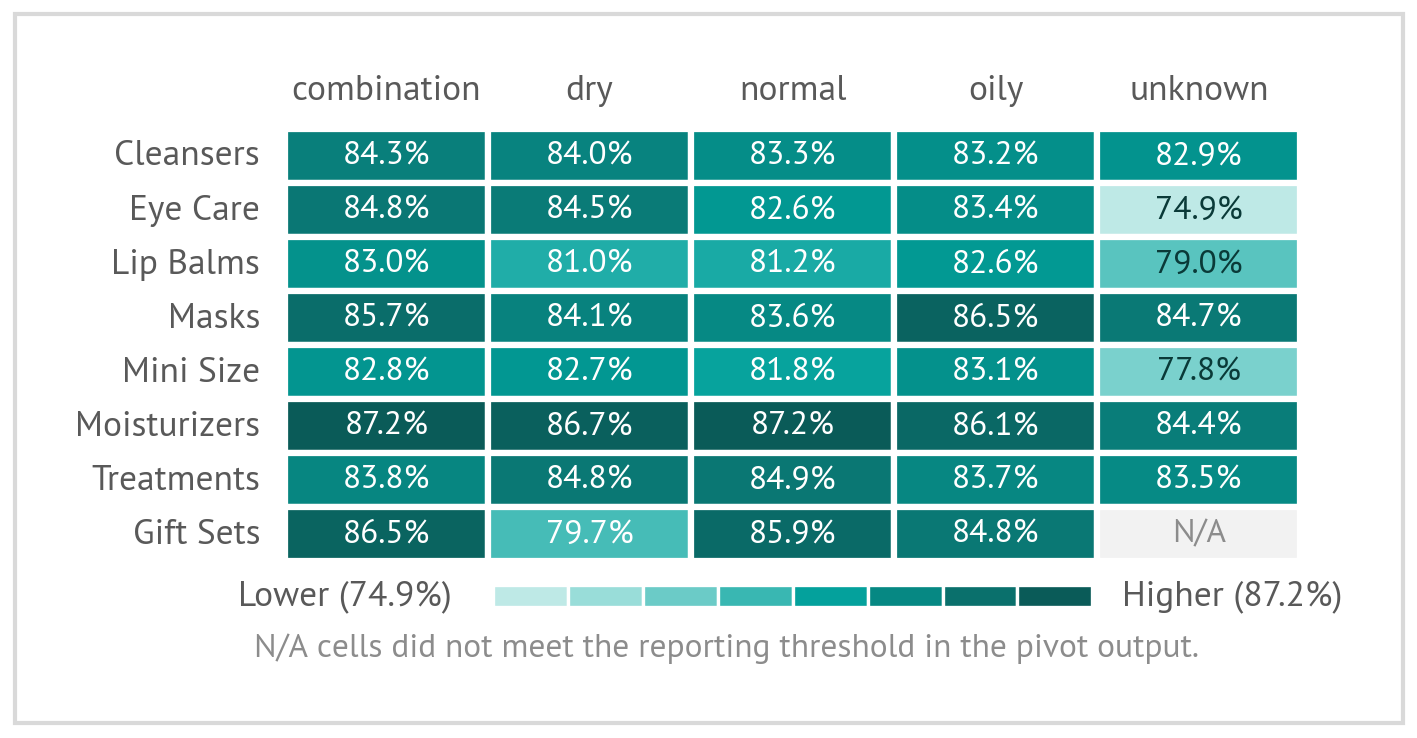

In [6]:
draw_heatmap(pivot, OUTPUT_PATH)

print(f"Wrote {OUTPUT_PATH}")
print(f"Wrote {OUTPUT_PATH.with_suffix('.svg')}")
display(Image(filename=str(OUTPUT_PATH)))